In [1]:
#import sys
from pywinauto.application import Application, ProcessNotFoundError
from pywinauto import timings
from tkinter import Tk, filedialog
#import os
#import re
import time

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [3]:
# Constants
time_sleep = 0.5

In [4]:
# Hide main Tk window
root = Tk()
root.withdraw()

''

In [5]:
# Path to the Windows application executable
app_exe = r"c:\DimDev\DataTools\Read_BIN\ISON_321_20250314\ISON_321.exe"  # TODO: Update this path

In [6]:
# Start the application
app = Application(backend="uia").start(app_exe)
time.sleep(time_sleep)

In [7]:
dlg_select_mode = app.window(title=r"Select program type")
dlg_select_mode.wait('visible', timeout=1)
print("Started a new instance of the application.")

<uiawrapper.UIAWrapper - 'Select program type', Dialog, 6622474501497574314>

Started a new instance of the application.


In [8]:
# Try to click the OK button (case-insensitive, anywhere in text)
ok_button = dlg_select_mode.child_window(title="OK", control_type="Button")
ok_button.click_input()
time.sleep(time_sleep)

Case then application start at first and not close after task is done

In [1063]:
# try:
#     # Try to connect to a running instance
#     app = Application(backend="uia").connect(path=app_exe)
#     print("Application is already running. Connected to the existing instance.")
#     time.sleep(time_sleep)
# except ProcessNotFoundError:
#     # If not running, start a new instance
#     app = Application(backend="uia").start(app_exe)
#     dlg_select_mode = app.window(title=r"Select program type")
#     dlg_select_mode.wait('visible', timeout=2)
#     print("Started a new instance of the application.")
#     # Try to click the OK button (case-insensitive, anywhere in text)
#     ok_button = dlg_select_mode.child_window(title="OK", control_type="Button")
#     ok_button.click_input()
#     time.sleep(time_sleep)

In [1064]:
# Print all controls for debugging
#dlg.print_control_identifiers()

In [1065]:
# Print captured title from main window
#print(f"Captured window title: {dlg.window_text()}")

In [1066]:
# Select a program type from the ComboBox
#combo = dlg.child_window(auto_id="ProgramTypeSelector.programType", control_type="ComboBox")
#combo.select("ISON Pro")  # or any other item from the list

# Click the OK button
#ok_btn = dlg.child_window(title="OK", control_type="Button")
#ok_btn.click_input()

Open menu item "Convert", pause, select "Convert data to bin file ..."

In [9]:
# Access the main window again if needed
main_win = app.top_window()
print(f"Captured window title: {main_win.window_text()}")
time.sleep(time_sleep)

Captured window title: Select program type


In [ ]:
# Print all MenuItem controls in the main window
print("Menu items after clicking Convert:")
for item in main_win.descendants(control_type="MenuItem"):
    print(item.window_text())

In [ ]:
# Open the "Convert" menu
convert_menu = main_win.child_window(title="Convert", control_type="MenuItem")
print(f"Captured menu item: {convert_menu.window_text()}")
convert_menu.click_input()
time.sleep(time_sleep)  # Pause for 1 second

In [1070]:
print("Submenu items under Convert:")
for item in convert_menu.descendants(): #control_type="MenuItem"
    print(item.window_text())

Submenu items under Convert:

Report of experiment...
ADC -> Clb data...
Convert to Raw IMU data...
Convert to IMR data...
Convert to DMR data...
Convert log data to bin file...
Combine RAWIMUB and GNSS data...

*.amd -> *.prm...
*.prm -> *.amd...
*.prm -> *.hdr...

*.cdx -> *.txt...
*.cpx -> *.txt...


In [1071]:
# Select "Convert data to bin file ..."
convert_log2bin_item = main_win.child_window(title="Convert log data to bin file...", control_type="MenuItem")
convert_log2bin_item.click_input()
time.sleep(time_sleep)  # Wait for dialog to appear

convert_log2bin_item.click_input() open dialog window to select file, how i can see list of files for selecting and then select one?

In [1072]:
# Check files in the dialog
listview = main_win.child_window(control_type="List")
for item in listview.descendants(control_type="ListItem"):
    print(item.window_text())

F3003031.flash
INS_Converted.prm


Select *.flash file

In [1073]:
# Select the first .flash file from the list
flash_file = [item.window_text() for item in listview.descendants(control_type="ListItem") if item.window_text().endswith(".flash")][0]
flash_file

'F3003031.flash'

In [1074]:
# Select a file by its name (replace with your actual file name)
#target_file = item.window_text() # we waiting for only one file in the list
file_item = listview.child_window(title=flash_file, control_type="ListItem")
file_item.click_input()
time.sleep(time_sleep)  

In [1075]:
# Find button to open the file
print("All elements in child window:")
Open_file_window = main_win.child_window(title="Open file")
for element in Open_file_window.descendants(title="Відкрити"):
    print(f"{element.element_info.control_type}: {element.window_text()}")
    if element.window_text() == "Відкрити":
        open_btn = element

All elements in child window:
Button: Відкрити


In [1076]:
# test button
#open_btn = main_win.child_window(title="Відкрити")
#open_btn.element_info.control_type  # Print the button text
#open_btn.is_enabled()  # Check if the button exists

In [1077]:
# Click the Open button (if present)
open_btn = main_win.child_window(title="Відкрити", control_type=open_btn.element_info.control_type)
if open_btn.is_enabled():
    open_btn.click_input()
    time.sleep(time_sleep)  # Wait for the operation to complete
else:
    print("Open button not found or not enabled.")

Select INS.txt

In [1078]:
# Check files in the dialog
listview2 = main_win.child_window(control_type="List")
for item in listview2.descendants(control_type="ListItem"):
    print(item.window_text())

INS


In [1079]:
# Choose only one file
target_log_file = [item.window_text() for item in listview2.descendants(control_type="ListItem", title="INS")][0]
target_log_file

'INS'

In [1080]:
# Select a file by its name (replace with your actual file name)
file_item = listview.child_window(title=target_log_file, control_type="ListItem")
file_item.click_input()
time.sleep(time_sleep)

In [1081]:
# Click the Open button (if present)
if open_btn.is_enabled():
    open_btn.click_input()
    time.sleep(time_sleep)  # Wait for the operation to complete
else:
    print("Open button not found or not enabled.")

Waiting for processing log file and click final "OK" button<br>
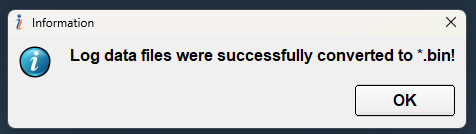

In [1082]:
# Use a while True loop to continuously check for the appearance of the Information_window.
# Once it appears, break the loop and continue with your process.
while True:
    Information_window = main_win.child_window(title="Information")
    if Information_window.exists():
        break
    time.sleep(1)

Information_window.wait('visible', timeout=time_sleep)

<uiawrapper.UIAWrapper - 'Information', Dialog, -1652412713620978707>

In [1083]:
# Find OK button in the Information window
print("All elements in child window (Information):")
for element in Information_window.descendants():
    print(f"{element.element_info.control_type}: {element.window_text()}")
    if element.window_text() == "OK":
        ok_btn = element

All elements in child window (Information):
TitleBar: 
MenuBar: Система
MenuItem: Система
Button: Закрити
Image: 
Text: Log data files were successfully converted to *.bin!
Group: 
Button: OK


In [1084]:
# Click the button OK
#open_btn = main_win.child_window(title="OK", control_type=ok_btn.element_info.control_type)
#open_btn.window_text()
#open_btn.click_input()
ok_btn.window_text()
ok_btn.click_input()
time.sleep(time_sleep)

'OK'

# Convert bin file to txt

In [1085]:
# Make sure the main window is active
from pywinauto.keyboard import send_keys
main_win.set_focus()
time.sleep(0.5)

# Send F8 key to open the dialog window
send_keys('{F8}')
time.sleep(time_sleep)  # Wait for the dialog to appear

<uiawrapper.UIAWrapper - 'Inertial Labs ISON v.3.2.1.2', Dialog, -4285493859867860945>

In [1086]:
# Find INS_Converted.BIN file in the dialog
list_bin_files = main_win.child_window(control_type="List")
for element in list_bin_files.descendants(control_type="ListItem"):
    if element.window_text() == "INS_Converted":
        bin_file = element
    print(element.window_text())

INS_Converted


In [1087]:
# Select a file by its name (replace with your actual file name)
bin_file.click_input()
time.sleep(time_sleep)

In [1088]:
# Click the Open button (if present)
if open_btn.is_enabled():
    open_btn.click_input()
    time.sleep(time_sleep)  # Wait for the operation to complete
else:
    print("Open button not found or not enabled.")

Waiting for processing log file and click final "OK" button<br><br>
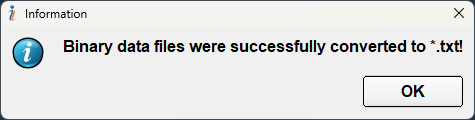

In [1089]:
while True:
    Information_window2 = main_win.child_window(title="Information")
    if Information_window2.exists():
        break
    time.sleep(1)

Information_window2.wait('visible', timeout=time_sleep)

<uiawrapper.UIAWrapper - 'Information', Dialog, -2536743119866523715>

In [1090]:
# Extract the final "OK" button from the Information window
for element in Information_window2.descendants():
    print(f"{element.element_info.control_type}: {element.window_text()}")
    if element.window_text() == "OK":
        ok_btn2 = element

TitleBar: 
MenuBar: Система
MenuItem: Система
Button: Закрити
Image: 
Text: Binary data files were successfully converted to *.txt!
Group: 
Button: OK


In [1091]:
# Confirm the OK button is present and click it
ok_btn2.click_input()
time.sleep(time_sleep)

# Close application

In [1092]:
if not Information_window.exists():
       main_win.close()

In [1093]:
# Check if the Information window exists and print its text
# if not Information_window.exists():
#     print(Information_window.window_text())
# else:
#     print("Information window not enabled.")

# Check paths for timestamp_geo_parser.py

In [7]:
import os

In [5]:
# Usage: python timestamp_geo_parser.py <raw_folder> <ison_data_folder> <app_exe>
root_folder = r"C:\DimDev\DataTools\Read_BIN"
ison_exe = r"ISON_321.exe"
ison_folder = r"ISON_321_20250314"
raw_folder = os.path.join(root_folder, "raw")
ison_data_folder = os.path.join(root_folder, ison_folder, "data")
app_exe = os.path.join(root_folder, ison_folder, ison_exe)
processed_folder = os.path.join(root_folder, "processed")

In [8]:
os.getcwd()

'c:\\DimDev\\DataTools\\Read_BIN\\sandbox'

In [6]:
print("Root folder:", root_folder)
print("Raw folder:", raw_folder)
print("Processed folder:", processed_folder)
print("ISON data folder:", ison_data_folder)
print("App executable:", app_exe)

Root folder: C:\DimDev\DataTools\Read_BIN
Raw folder: C:\DimDev\DataTools\Read_BIN\raw
Processed folder: C:\DimDev\DataTools\Read_BIN\processed
ISON data folder: C:\DimDev\DataTools\Read_BIN\ISON_321_20250314\data
App executable: C:\DimDev\DataTools\Read_BIN\ISON_321_20250314\ISON_321.exe
